In [1]:
import matplotlib.pyplot as plt
import os
import csv
import random
import numpy as np
from scipy.stats import norm 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter
import datetime
import re
import casadi as ca
#import l4casadi as l4c
import time

2025-09-22 15:09:41.421496: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 15:09:42.333240: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def find_latest_directory(base_dir):
    """Finds the latest dated directory in the base directory."""
    subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    latest_directory = max(subdirs, key=lambda d: os.path.getmtime(os.path.join(base_dir, d)))
    return os.path.join(base_dir, latest_directory)

def find_latest_dataset_directory(polar, fixed_view, ripe):
    script_dir = os.getcwd()
    base_dir = os.path.join(script_dir, "datasets")
    
    base_dir = os.path.join(base_dir, "polar" if polar else "cartesian")
    base_dir = os.path.join(base_dir, "fixed_view" if fixed_view else "variable_view")
    base_dir = os.path.join(base_dir, "ripe" if ripe else "raw")

    latest_dataset_directory = find_latest_directory(base_dir=base_dir)
    return latest_dataset_directory

def generate_augmented_data(X, num_samples):
    x_min = (np.sqrt(X[:, 0]**2 + X[:, 1]**2)).min()
    x_max = (np.sqrt(X[:, 0]**2 + X[:, 1]**2)).max()
    yaw_values = [30, -30, 60, -60, 90, -90, 180, -180]
    
    synthetic_X = []
    synthetic_Y = []
    
    for _ in range(num_samples):
        theta = random.uniform(-np.pi, np.pi)
        r = random.choice([random.uniform(0, x_min), random.uniform(x_max, x_max +5)])
        a = r * np.cos(theta) 
        b = r * np.sin(theta)
        c = np.radians(random.choice(yaw_values))
        value = 0.5
        synthetic_X.append([a, b, c])
        synthetic_Y.append(value)
    return np.array(synthetic_X), np.array(synthetic_Y)


def load_data(polar=False, fixed_view=False, ripe=True, n_input=3, augment_data=True):
    latest_dataset_directory = find_latest_dataset_directory(polar, fixed_view, ripe)
    output_csv_filename = 'SurrogateDatasetCNN.csv'
    DATA_PATH = os.path.join(latest_dataset_directory, output_csv_filename)
    print(f"Loading data from: {DATA_PATH}")

    X = []  
    Y = []

    with open(DATA_PATH, 'r') as infile:
        data = csv.reader(infile)
        next(data)
        for row in data:
            a, b, c, _, value_raw, value_ripe, _ = map(float, row)
            
            if n_input == 3:
                X.append([a, b, c])
            else:
                X.append([a, b])
            
            Y.append( ( value_ripe if ripe else (value_raw)))
    
    X_np = np.array(X)
    Y_np = np.array(Y)
    
    if augment_data:
        synthetic_X, synthetic_Y = generate_augmented_data(X_np, int(len(X_np)*0.2))

        X_tensor = torch.tensor(np.concatenate((X_np, synthetic_X), axis=0), dtype=torch.float)
        Y_tensor = torch.tensor(np.concatenate((Y_np, synthetic_Y), axis=0), dtype=torch.float)
        return X_tensor, Y_tensor
    else:
        return  torch.tensor(X_np, dtype=torch.float), torch.tensor(Y_np, dtype=torch.float)
    
def generate_xytheta_grid(
    samples_xy, 
    samples_yaw=None, 
    x_low=-8,
    x_high=8,
    y_low=-8,
    y_high=8,
):
    synthetic_XY = []
    x_range = np.linspace(x_low, x_high, samples_xy)
    y_range = np.linspace(y_low, y_high, samples_xy)
    yaw_range = np.linspace(-np.pi, np.pi, samples_yaw) if samples_yaw is not None else []

    for x in x_range:
        for y in y_range:
            yaw_set = yaw_range if samples_yaw is not None else [np.arctan2(-y, -x)]

            for yaw in yaw_set:
                drone_pos = np.array([x, y, yaw])
                
                synthetic_XY.append(
                    drone_pos
                )
    return torch.Tensor(np.array(synthetic_XY))

In [3]:
import torch.nn.functional as F
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size=64,
        hidden_layers=3,
        output_dim=2,
        threshold=8.0,
        gate_slope=10.0,
    ):
        super().__init__()
        in_features = input_dim if input_dim != 3 else input_dim + 1
        self.input_layer = torch.nn.Linear(in_features, hidden_size)
        self.hidden_layers = torch.nn.ModuleList(
            [torch.nn.Linear(hidden_size, hidden_size) for _ in range(hidden_layers)]
        )
        self.out_layer = torch.nn.Linear(hidden_size, output_dim)

        # register as buffers so they carry device+dtype+wrapper keys
        self.register_buffer('threshold', torch.tensor(threshold))
        self.register_buffer('gate_slope', torch.tensor(gate_slope))

    def forward(self, x):
        if x.shape[-1] == 3:
            sin_cos = torch.cat([torch.sin(x[..., -1:]),
                                 torch.cos(x[..., -1:])], dim=-1)
            x = torch.cat([x[..., :-1], sin_cos], dim=-1)

        raw_2d = x[..., :2]
        norm2d = raw_2d.norm(dim=-1)

        # these are 0‑d tensors that broadcast, 
        # keep functorch wrappers and device info
        gate = torch.sigmoid(self.gate_slope * (self.threshold - norm2d))

        h = torch.tanh(self.input_layer(x))
        for layer in self.hidden_layers:
            h = torch.tanh(layer(h))
        logits = self.out_layer(h)

        gated_logits = logits * gate.unsqueeze(-1)
        return F.softmax(gated_logits, dim=-1)

In [4]:
import os
import datetime
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import csv

# FLAGS
train = False
fixed_view = False
polar = False
class_ripe = True  # if False: training is done for class unripe

# MLP PARAMS
nn_input_dim = 3
output_dim = 2
hidden_size = 64
hidden_layers = 3

validation_split = 0.35
batch_size = 1
epochs = 20
lr = 1e-3 

# Load data
X, Y = load_data(fixed_view=fixed_view, ripe=class_ripe, augment_data=True)
if class_ripe :
    Y = torch.stack([Y, 1 - Y], axis=1)  # (N, 2)
else:
    Y = torch.stack([1 - Y, Y], axis=1)  # (N, 2)
    
if train:
    # Base directory to save models
    base_model_dir = find_latest_dataset_directory(polar, fixed_view, class_ripe)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    run_model_dir = os.path.join(base_model_dir, timestamp)
    os.makedirs(run_model_dir, exist_ok=True)
    print("Models will be saved in:", run_model_dir)

    # Prepare data
    X = X[:, :3]
    dataset = TensorDataset(X, Y)
    num_train_samples = int((1 - validation_split) * len(dataset))
    num_val_samples = len(dataset) - num_train_samples
    train_dataset, val_dataset = random_split(dataset, [num_train_samples, num_val_samples])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Model, loss, optimizer
    model = MultiLayerPerceptron(input_dim=nn_input_dim, hidden_size=hidden_size, hidden_layers=hidden_layers, output_dim=2)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(model)

    # Tensorboard log
    log_dir = f"runs/fcn_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
    writer = SummaryWriter(log_dir)

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        writer.add_scalar('Loss/train', avg_train_loss, epoch)
        writer.add_scalar('Loss/val', avg_val_loss, epoch)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            model_path = os.path.join(run_model_dir, f"best_model_epoch_{epoch+1}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"Model saved to {model_path}")

    writer.close()

Loading data from: /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/ripe/2025-03-29_20-28-15/SurrogateDatasetCNN.csv


In [5]:
if train:
    import matplotlib.pyplot as plt
    import csv
    print(train_losses)
    print(val_losses)
    # Plot dei loss
    plt.figure(figsize=(6,2.5))
    plt.plot(range(epochs), train_losses, label='Train Loss', linewidth=2)
    plt.plot(range(epochs), val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def get_latest_best_model(nn_input_dim, ripe, polar, fixed_view):
    # Base directory to save models
    find_latest_dataset_directory(polar, fixed_view, ripe)
    base_model_dir = find_latest_dataset_directory(polar, fixed_view, ripe)

    timestamp_pattern = re.compile(r"^\d{8}_\d{6}$")

    # Filtra le directory che rispettano il formato
    run_dirs = [
        d for d in os.listdir(base_model_dir)
        if os.path.isdir(os.path.join(base_model_dir, d)) and timestamp_pattern.match(d)
    ]

    if not run_dirs:
        raise ValueError(f"No valid run directories found in: {base_model_dir}")

    # Ordina le directory per nome decrescente (più recente = più grande come stringa)
    run_dirs.sort(reverse=True)

    latest_run_dir = os.path.join(base_model_dir, run_dirs[0])

    # find all files matching the best model naming pattern
    best_model_files = [
        f for f in os.listdir(latest_run_dir)
        if re.match(r"best_model_epoch_(\d+)\.pth", f)
    ]
    if not best_model_files: raise ValueError(f"No best model files found in: {latest_run_dir}")
    
    # Pick the file with the highest epoch number.
    latest_model = max(
        best_model_files,
        key=lambda f: int(re.match(r"best_model_epoch_(\d+)\.pth", f).group(1))
    )
    
    loaded_model = os.path.join(latest_run_dir, latest_model)
    print(f'Loaded model: {loaded_model}')

    return loaded_model

Loaded model: /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/ripe/2025-03-29_20-28-15/20250725_171852/best_model_epoch_20.pth
/home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/ripe/2025-03-29_20-28-15/20250725_171852/best_model_epoch_20.pth


/tmp/ipykernel_531066/729263560.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_nn_tensor = torch.tensor(X_nn, dtype=torch.float32)


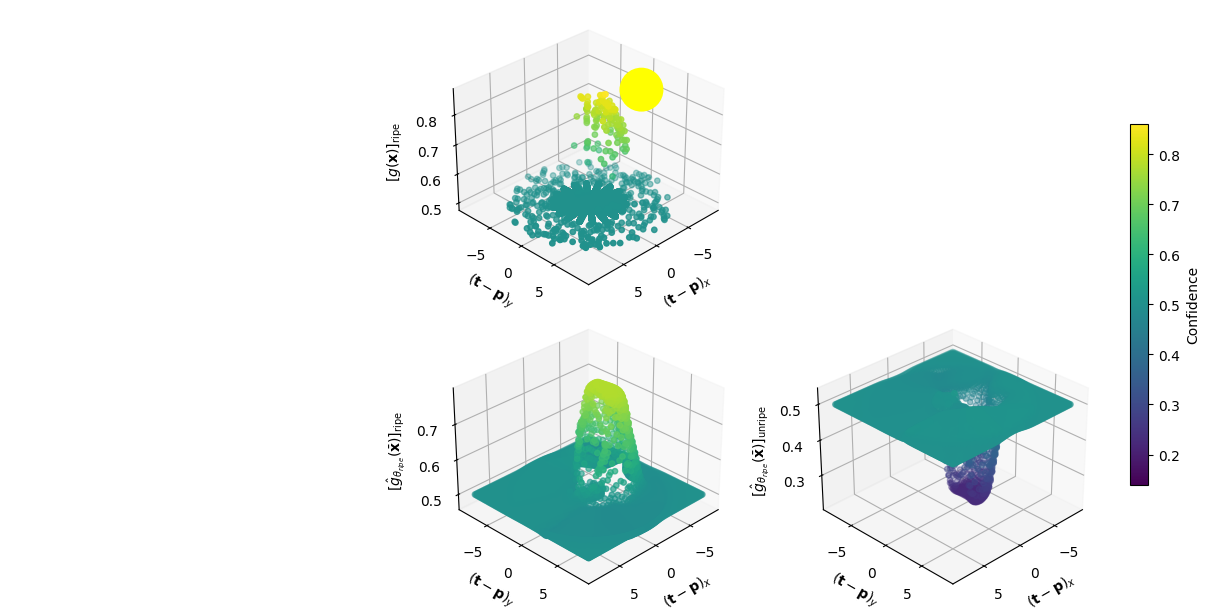

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator

def add_orange_scatter(ax, center=(-8.0, 0.0, 0.8), r=0.3, target=(0.0, 0.0, 0.5), marker_size=1000):
    cx, cy, cz = center
    ax.scatter([cx], [cy], [cz], s=marker_size, color='yellow', edgecolors='none', zorder=5)
    vdir = np.array(target) - np.array(center)
    norm = np.linalg.norm(vdir)
    if norm == 0:
        vdir = np.array([0.0, 0.0, -1.0]); norm = 1.0
    d = vdir / norm
    L = 5.0 * r
    vec = d * L
    # Uncomment if you want the arrow
    # ax.quiver(cx, cy, cz, vec[0], vec[1], vec[2],
    #           color='orange', linewidth=4, arrow_length_ratio=0.25, pivot='tail')

# === NN Inference ===
X_nn = generate_xytheta_grid(
    samples_xy=80, samples_yaw=None,
    x_low=-8, x_high=8, y_low=-8, y_high=8
)

model = MultiLayerPerceptron(input_dim=nn_input_dim, hidden_size=hidden_size, hidden_layers=hidden_layers, output_dim=output_dim)
state_path = get_latest_best_model(nn_input_dim, class_ripe, polar, fixed_view)
print(state_path)
state_dict = torch.load(state_path, map_location='cuda')
model.load_state_dict(state_dict)
model.eval()

X_nn_tensor = torch.tensor(X_nn, dtype=torch.float32)
X_nn_input = X_nn_tensor[:, :nn_input_dim]
with torch.no_grad():
    y_test = model(X_nn_input).detach().numpy()

X_nn_np = X_nn_tensor.numpy()
X_np    = X.numpy()
Y_np    = Y.numpy()

# Separate outputs
y_test_1, y_test_2 = y_test[:, 0], y_test[:, 1]
Y_1, Y_2 = Y_np[:, 0], Y_np[:, 1]

# === Layout: 2x3 grid ===
fig = plt.figure(figsize=(12, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# First column empty
ax_e1 = fig.add_subplot(gs[0, 0]); ax_e1.axis("off")
ax_e2 = fig.add_subplot(gs[1, 0]); ax_e2.axis("off")

# (0,1) Ground Truth
ax1 = fig.add_subplot(gs[0, 1], projection='3d')
sc1 = ax1.scatter(X_np[:, 0], X_np[:, 1], Y_1, c=Y_1, cmap='viridis', s=15)
ax1.set_xlabel(r'$(\mathbf{t} - \mathbf{p})_x$')
ax1.set_ylabel(r'$(\mathbf{t} - \mathbf{p})_y$')
ax1.set_zlabel(r'[$g(\mathbf{x})]_\mathrm{ripe}$' if class_ripe else r'[$g(\mathbf{x})]_\mathrm{unripe}$')
ax1.view_init(elev=30, azim=45)
ax1.zaxis.set_rotate_label(False)
ax1.zaxis.label.set_rotation(90)
add_orange_scatter(ax1)

# (0,2) Empty
ax_empty = fig.add_subplot(gs[0, 2])
ax_empty.axis("off")

# (1,1) NN Prediction y₁
ax2 = fig.add_subplot(gs[1, 1], projection='3d')
sc2 = ax2.scatter(X_nn_np[:, 0], X_nn_np[:, 1], y_test_1, c=y_test_1, cmap='viridis', s=15)
ax2.set_xlabel(r'$(\mathbf{t} - \mathbf{p})_x$')
ax2.set_ylabel(r'$(\mathbf{t} - \mathbf{p})_y$')
ax2.set_zlabel(r'$[\hat{g}_{\theta_{ripe}}(\bar{\mathbf{x}})]_\mathrm{ripe}$' if class_ripe else r'$[\hat{g}_{\theta_{unripe}}(\bar{\mathbf{x}})]_\mathrm{unripe}$')
ax2.view_init(elev=30, azim=45)
ax2.zaxis.set_rotate_label(False)
ax2.zaxis.label.set_rotation(90)

# (1,2) NN Prediction y₂
ax3 = fig.add_subplot(gs[1, 2], projection='3d')
sc3 = ax3.scatter(X_nn_np[:, 0], X_nn_np[:, 1], y_test_2, c=y_test_2, cmap='viridis', s=15)
ax3.set_xlabel(r'$(\mathbf{t} - \mathbf{p})_x$')
ax3.set_ylabel(r'$(\mathbf{t} - \mathbf{p})_y$')
ax3.set_zlabel(r'$[\hat{g}_{\theta_{ripe}}(\bar{\mathbf{x}})]_\mathrm{unripe}$' if class_ripe else r'$[\hat{g}_{\theta_{unripe}}(\bar{\mathbf{x}})]_\mathrm{ripe}$')
ax3.view_init(elev=30, azim=45)
ax3.zaxis.set_rotate_label(False)
ax3.zaxis.label.set_rotation(90)

# Format ticks
for ax in (ax1, ax2, ax3):
    ax.zaxis.set_major_locator(MultipleLocator(0.1))

# Shared color limits
vmin = min(Y_1.min(), Y_2.min(), y_test_1.min(), y_test_2.min())
vmax = max(Y_1.max(), Y_2.max(), y_test_1.max(), y_test_2.max())
for sc in (sc1, sc2, sc3):
    sc.set_clim(vmin=vmin, vmax=vmax)

fig.colorbar(sc3, ax=[ax1, ax2, ax3], fraction=0.025, pad=0.05, label='Confidence')

# Salvataggi
plt.savefig("nn_all_outputs_matrix.png", dpi=1500, bbox_inches="tight", pad_inches=0.5, transparent=True)
plt.show()


/tmp/ipykernel_531066/1982715006.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_yaw_tensor = torch.tensor(X_yaw_scan, dtype=torch.float32)


Peak ĝ(unripe, unripe) at x=-2.02, y=0.08


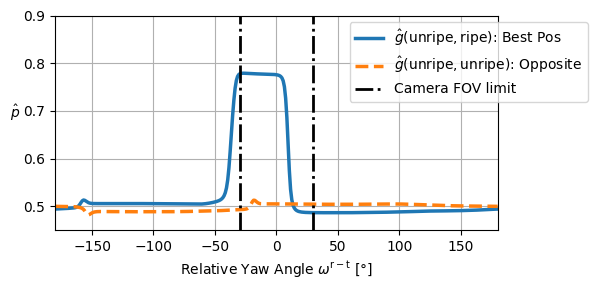

In [8]:

# === Yaw-based Surrogate Curve ===
X_yaw_scan = generate_xytheta_grid(
    samples_xy=100, samples_yaw=360,
    x_low=-8, x_high=8, y_low=-8, y_high=8
)

X_yaw_tensor = torch.tensor(X_yaw_scan, dtype=torch.float32)
X_yaw_input = X_yaw_tensor[:, :nn_input_dim]

with torch.no_grad():
    y_full = model(X_yaw_input).detach().numpy()

best_idx = np.argmax(y_full[:, ~class_ripe])
x_peak, y_peak = X_yaw_scan[best_idx, 0], X_yaw_scan[best_idx, 1]
print(f"Peak ĝ(unripe, unripe) at x={x_peak:.2f}, y={y_peak:.2f}")
yaw_values = np.linspace(-np.pi, np.pi, 360)

X_best_yaw = np.column_stack([
    np.full_like(yaw_values, x_peak),
    np.full_like(yaw_values, y_peak),
    (yaw_values - X_yaw_scan[best_idx, -1].numpy()) % (2 * np.pi)
])

X_opposite_yaw = np.column_stack([
    -X_best_yaw[:, 0],
    -X_best_yaw[:, 1],
    (yaw_values - X_yaw_scan[best_idx, -1].numpy() + np.pi) % (2 * np.pi)
])

X_best_tensor = torch.tensor(X_best_yaw, dtype=torch.float32)
X_opposite_tensor = torch.tensor(X_opposite_yaw, dtype=torch.float32)

with torch.no_grad():
    y_best_curve = model(X_best_tensor).detach().numpy()
    y_opposite_curve = model(X_opposite_tensor).detach().numpy()

y_best = y_best_curve[:, ~class_ripe].flatten()
y_opposite = y_opposite_curve[:, ~class_ripe].flatten()

# Plot yaw curve
plt.figure(figsize=(6, 3))
plt.plot(np.rad2deg(yaw_values), y_best, label=r'$\hat{g}(\mathrm{unripe}, \mathrm{ripe})$: Best Pos', linewidth=2.5)
plt.plot(np.rad2deg(yaw_values), y_opposite, label=r'$\hat{g}(\mathrm{unripe}, \mathrm{unripe})$: Opposite', linestyle='--', linewidth=2.5)

plt.axvline(x=-30, color='black', linestyle='-.', linewidth=2.0, label='Camera FOV limit')
plt.axvline(x=30, color='black', linestyle='-.', linewidth=2.0)

#plt.title("Surrogate NN with Varying Yaw: $\hat{g}(\mathrm{unripe}, \mathrm{unripe})$", fontsize=14)
plt.xlabel(r'Relative Yaw Angle $\omega^{\mathrm{r-t}}$ [°]')
plt.ylabel(r'$\hat{p}$', rotation=0, labelpad=6)
plt.xlim([-180, 180])
plt.ylim([0.45, 0.9])
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0.65, 1))
plt.grid(True)
plt.tick_params(labelsize=10)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))

plt.tight_layout()
plt.savefig("nn_yaw_curve_unripe_unripe_peak_based.png", dpi=300)
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
import l4casadi as l4c

ENTROPY_DECAY = -2 # decay exponent for future entropy
ENTROPY_SCALE = -40
SIGMOID_STEEPNESS = 10.0
DIST_THRESHOLD = 9.0

N = 10
dt = 0.25
T = dt * N
nx = 3
n_control = nx
n_state = nx * 2
initial_randomic = True

sensing_radius_sq = 3.0**2

# Constants for cost weights
Q_dist = 1e-3

# Attraction term
W_entropy =1.0
# Control effort penalty
W_xy_accel = 1e-3
W_theta_accel = 1e-3
class NeuralMPC:
    def __init__(self, g_nn, run_dir=None, num_trees=5):
        np.random.seed(30)
        [self.g_nn_ripe, self.g_nn_raw] = g_nn

        self.current_robot_state = None

        self.trees_pos = self._get_trees_poses(num_trees)
        self.lb, self.ub = self.get_domain(self.trees_pos)
        
        self.current_robot_state = self.generate_random_initial_state(margin=1.5).flatten() if initial_randomic else  np.array([self.lb[0] + 1.0, (self.lb[1]+self.ub[1])/2.0, 0.0])
        
        self.num_total_trees = self.trees_pos.shape[0]
        self.true_tree_states = np.random.choice([1, 1], size=(self.num_total_trees))
        self.latest_trees_scores = np.full((self.num_total_trees, 2), 0.5) 
        self.beliefs_k = ca.DM.ones(self.num_total_trees, 2) * 0.5

        self.entropy_func = self.entropy_f(self.num_total_trees)
        self.bayes_func = self.bayes_multiclass(self.num_total_trees, 2)

        self.save_folder = run_dir if run_dir is not None else "./simulation_results"
        os.makedirs(self.save_folder, exist_ok=True)


    def _get_trees_poses(self, num_trees, space=4.0):
        coords = np.arange(0.1, num_trees * space, space)
        grid_x, grid_y = np.meshgrid(coords, coords)
        return np.column_stack((grid_x.ravel(), grid_y.ravel()))

    def _robot_state_update(self):
        return self.current_robot_state + np.random.uniform(0.001, nx)

    def _tree_scores_sensor(self):
        for i in range(self.num_total_trees):
            diff_robot_tree = self.trees_pos[i, :2] - np.array(self.current_robot_state).flatten()[:2]
            drone_yaw = np.array(self.current_robot_state).flatten()[2]

            angle_robot_tree = np.arctan2(diff_robot_tree[1],diff_robot_tree[0])
            angle_align = np.cos(angle_robot_tree)*np.cos(drone_yaw) + np.sin(angle_robot_tree)*np.sin(drone_yaw)

            dist_sq = np.sum((diff_robot_tree)**2)
            value = angle_align * 0.75 if dist_sq < sensing_radius_sq and (angle_align >= np.cos(np.pi/6.0)) else 0.5

            self.latest_trees_scores[i, ~(self.true_tree_states[i])] = value
            self.latest_trees_scores[i, self.true_tree_states[i]] = 1-value

    @staticmethod
    def get_domain(tree_positions):
        return  [np.min(tree_positions[:, 0]), np.min(tree_positions[:, 1])], \
                [np.max(tree_positions[:, 0]), np.max(tree_positions[:, 1])]

    @staticmethod
    def kin_model(nx_pose, dt): # nx_pose is 3 (x,y,theta)
        nx_full = nx_pose * 2 # Full state [px,py,pw,vx,vy,vw] = 6
        nu = nx_pose          # Control [ax,ay,aw] = 3
        
        x_sym = ca.SX.sym('x', nx_full)
        u_sym = ca.SX.sym('u', nu)
        
        px, py, pw, vx, vy, vw = [x_sym[i] for i in range(nx_full)]
        ax, ay, aw = [u_sym[i] for i in range(nu)]
        
        x_dot = ca.vertcat(vx, vy, vw, ax, ay, aw)
        f_continuous = ca.Function('f_cont', [x_sym, u_sym], [x_dot])
        
        k1 = f_continuous(x_sym, u_sym)
        k2 = f_continuous(x_sym + dt / 2 * k1, u_sym)
        k3 = f_continuous(x_sym + dt / 2 * k2, u_sym)
        k4 = f_continuous(x_sym + dt * k3, u_sym)
        x_next = x_sym + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        
        F = ca.Function('F', [x_sym, u_sym], [x_next])
        return F

    @staticmethod
    def bayes_multiclass(n_targets, n_classes):
        prior = ca.MX.sym("prior", n_targets, n_classes)
        likelihood = ca.MX.sym("likelihood", n_targets, n_classes)

        unnorm = prior * likelihood
        norm = ca.sum1(unnorm) if n_targets == 1 else ca.repmat(ca.sum2(unnorm), 1, n_classes)
        posterior = unnorm / norm 

        return ca.Function("bayes_multiclass", [prior, likelihood], [posterior])

    @staticmethod
    def entropy_f(num_targets):
        p = ca.MX.sym(f'input_entropy_f{num_targets}_dim', num_targets, 2)
        eps = 1e-8
        p_clipped = ca.fmax(eps, ca.fmin(1 - eps, p))
        entropy_per_target = -ca.sum2( p_clipped * (ca.log(p_clipped)/ca.log(2)) )
        return ca.Function(f'entropy_f_{num_targets}_dim', [p], [entropy_per_target])

    def mpc_opt(self, x0_full_state, steps_N):
        opti = ca.Opti()
        F_dynamics = self.kin_model(nx, dt)

        X = opti.variable(n_state, steps_N + 1)
        U = opti.variable(n_control, steps_N)
        
        P_X0_full = opti.parameter(n_state)
        P_TargetLambdas = opti.parameter(self.num_total_trees, 2)

        cost_total = 0
        cost_control_effort = 0
        attraction = 0
        cost_entropy = 0
        
        lambda_evolution_over_horizon = [P_TargetLambdas]
        nn_input_batch_over_horizon = []
        dist_array = []
        
        entropies = [self.entropy_func(lambda_evolution_over_horizon[0])]
        mask = ca.gt(entropies[0], 0.02)

        # Initial condition
        opti.subject_to(X[:, 0] == P_X0_full)

        # Dynamics, bounds, and costs over the horizon
        for i in range(steps_N):
            # State bounds (position, velocity)
            opti.subject_to(opti.bounded(self.lb[0] - 3.0, X[0, i], self.ub[0] + 3.0))    # x pos
            opti.subject_to(opti.bounded(self.lb[1] - 3.0, X[1, i], self.ub[1] + 3.0))    # y pos
            opti.subject_to(opti.bounded(-3*np.pi, X[2, i], +3*np.pi))          # theta
            
            opti.subject_to(opti.bounded(-1.75, X[3:5, i], 1.75))               # vx, vy
            opti.subject_to(opti.bounded(-np.pi/4, X[5, i], np.pi/4))           # vtheta

            # Control bounds (acceleration)
            opti.subject_to(opti.bounded(-5.0, U[0:2, i], 5.0))                 # ax, ay
            opti.subject_to(opti.bounded(-np.pi, U[2, i], np.pi))               # atheta
            
            # System dynamics
            opti.subject_to(X[:, i + 1] == F_dynamics(X[:, i], U[:, i]))
                                  
            # Collision avoidance with OBSTACLE trees
            safe_distance_sq = 1.25**2
            for j in range(self.num_total_trees):
                obs_j_pos = self.trees_pos[j, :]
                dist_sq_obs = ca.sumsqr(X[:2, i+1] - obs_j_pos.T)
                opti.subject_to(dist_sq_obs >= safe_distance_sq)
            
            cost_control_effort = cost_control_effort + \
                                  W_xy_accel * ca.sumsqr(U[:2, i]) + \
                                  W_theta_accel * ca.sumsqr(U[2, i])

            current_nn_input_step_i = []
            
            for j in range(self.num_total_trees):
                target_j_pos = self.trees_pos[j, :]
                diff_robot_to_target = X[:2, i + 1] - target_j_pos.T
                dist_array.append(ca.if_else(mask[j], ca.sumsqr(diff_robot_to_target), 1e20))
                robot_abs_heading = X[2, i+1] 
                nn_input_for_tree_j = ca.horzcat(diff_robot_to_target.T, robot_abs_heading)
                current_nn_input_step_i.append(nn_input_for_tree_j)
                
            min_d2 = dist_array[0]
            for d2 in dist_array[1:]:
                min_d2 = ca.fmin(min_d2, d2)
            attraction += Q_dist * min_d2
            
            nn_input_batch_over_horizon.append(ca.vcat(current_nn_input_step_i))

        # Batched inference
        nn_full_batch_input = ca.vcat(nn_input_batch_over_horizon)
        surrogate_output_ripe = self.g_nn_ripe(nn_full_batch_input)
        surrogate_output_raw = self.g_nn_raw(nn_full_batch_input)

        # Extend initial lambdas for processing (L0 has N_target_trees elements)
        L0_ext = ca.vcat([P_TargetLambdas for _ in range(steps_N)])

        # Deadzone boundaries
        sel = L0_ext[:, 0] >= L0_ext[:, 1]
        col1 = ca.if_else(sel, surrogate_output_ripe[:,0],  surrogate_output_ripe[:,1])
        col2 = ca.if_else(sel, surrogate_output_raw[:,0],   surrogate_output_raw[:,1])

        surrogate_output =  ca.horzcat(col1, col2)

        for i in range(steps_N):
            start_idx = i * self.num_total_trees
            end_idx = (i + 1) * self.num_total_trees
            obs_k_for_step_i = surrogate_output[start_idx:end_idx,:]
            lambda_next = self.bayes_func(lambda_evolution_over_horizon[-1], obs_k_for_step_i)
            lambda_evolution_over_horizon.append(lambda_next)
            entropies.append(self.entropy_func(lambda_next))
            cost_entropy -= ca.exp(ENTROPY_DECAY*i) * ca.logsumexp(-ENTROPY_SCALE * entropies[-1])
        
        # attraction modulation via sigmoid based on initial dist
        sigmoid = 1/(1+ca.exp(-SIGMOID_STEEPNESS*(min_d2-DIST_THRESHOLD)))
        mod_attr = attraction * sigmoid

        # total objective: control + attraction - info
        cost_total = cost_entropy
        opti.minimize(cost_total)

        # IPOPT options (removed HSL specific parts for wider compatibility)
        options = {
            "ipopt": {
                #"tol": 1e-5, # Relaxed tol for faster eval
                "warm_start_init_point": "yes",
                "print_level": 0, # Suppress IPOPT output
                "sb": "yes", # Suppress license messages
                "max_iter": 500, # Reduced max_iter
                "hessian_approximation":'limited-memory',
                #"mu_strategy": "monotone",
            },
            "print_time": False
        }
        opti.solver("ipopt", options)

        # Set initial values for parameters
        opti.set_value(P_X0_full, x0_full_state)
        opti.set_value(P_TargetLambdas, self.beliefs_k)
        param_inputs_for_func = [P_X0_full, P_TargetLambdas]
        decision_var_inputs_for_func = [opti.x, opti.lam_g]
        outputs_for_func = [U[:, 0], X, opti.x, opti.lam_g]

        try:
            sol = opti.solve()
            u_sol = sol.value(U[:, 0])
            x_traj_sol = sol.value(X)
            x_dec_sol = sol.value(opti.x) # Full decision variable vector
            lam_g_sol = sol.value(opti.lam_g) # Lagrangian multipliers for constraints
        except RuntimeError as e:
            print(f"IPOPT solve failed: {e}")

        # Create function AFTER first solve
        mpc_step_func = opti.to_function("mpc_step", 
                                         param_inputs_for_func + decision_var_inputs_for_func, 
                                         outputs_for_func)
        
        return (mpc_step_func,
                ca.DM(u_sol),
                ca.DM(x_traj_sol),
                ca.DM(x_dec_sol),
                ca.DM(lam_g_sol))

    def generate_random_initial_state(self, margin=1.5):
        max_attempts = 100
        for _ in range(max_attempts):
            x = np.random.uniform(self.lb[0] + margin, self.ub[0] - margin)
            y = np.random.uniform(self.lb[1] + margin, self.ub[1] - margin)
            valid = True
            for tree_pos_xy in self.trees_pos[:, :2]:
                if np.linalg.norm(np.array([x, y]) - tree_pos_xy) < margin:
                    valid = False
                    break
            if valid:
                theta = np.random.uniform(-np.pi, np.pi)
                return np.array([x, y, theta]).reshape(-1,1)
        # Fallback if no valid state found
        print("Warning: Could not find a valid random initial state away from trees. Using a default.")
        return np.array([self.lb[0] + margin, self.lb[1] + margin, 0.0]).reshape(-1,1)


    def run_simulation(self, max_sim_time_sec=120):
        F_dynamics = self.kin_model(nx, dt)

        # Initialize robot state
        initial_pose_xy_theta = self._robot_state_update()
        print(f"Simulation starting from: {initial_pose_xy_theta}")
        
        # Full state: [x, y, theta, vx, vy, vtheta]
        current_velocities_vx_vy_vtheta = ca.DM.zeros(nx) 
        current_full_state_x_k = ca.vertcat(ca.DM(initial_pose_xy_theta), current_velocities_vx_vy_vtheta)

        # Simulation data logging
        all_predicted_trajectories = []
        lambda_history_all_trees = []
        entropy_history_total = []
        mpc_step_durations = []
        actual_pose_history = []
        sim_time_history = []

        sim_start_wall_time = time.time()
        current_sim_logical_time = 0.0
        
        mpciter = 0
        
        is_first_mpc_solve = True

        # Store previous MPC solution for warm start
        prev_mpc_decision_vars_sol = None
        prev_mpc_lagrangian_multipliers_sol = None
        mpc_solver_function = None

        loop_condition = True
        
        max_iterations = int(max_sim_time_sec / dt)

        while loop_condition and mpciter < max_iterations:
            loop_iter_start_wall_time = time.time()
            current_sim_logical_time = loop_iter_start_wall_time - sim_start_wall_time
            print(f"\nMPC Iteration: {mpciter}, Sim Time: {current_sim_logical_time:.2f}s")

            # Update current robot pose (from previous command) for this iteration
            self.current_robot_state = current_full_state_x_k[:nx].full().flatten().tolist()
            actual_pose_history.append(self.current_robot_state)
            sim_time_history.append(current_sim_logical_time)

            # get tree scores
            self._tree_scores_sensor()
            self.beliefs_k = self.bayes_func(self.beliefs_k, ca.DM(self.latest_trees_scores))
            current_entropy_values = self.entropy_func(self.beliefs_k)
            total_current_entropy = ca.sum1(current_entropy_values).full().flatten()[0]
            print(f"Total Entropy: {total_current_entropy:.4f}")
            
            # Check termination condition (all trees low entropy)
            entropy_threshold_for_termination = 0.05 # More relaxed for mock
            if np.all(current_entropy_values.full().flatten() <= entropy_threshold_for_termination):
                print(f"All tree entropies <= {entropy_threshold_for_termination}. Mission complete.")
                loop_condition = False # This will be the last iteration's processing
            
            if not loop_condition and mpciter > 0: # If mission complete, break before next MPC solve
                 break
            
            mpc_solve_start_time = time.time()
            try:
                if is_first_mpc_solve or mpc_solver_function is None:
                    print("Running MPC opt (first step / cold start)...")
                    mpc_solver_function, u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = self.mpc_opt(
                        current_full_state_x_k, steps_N=N
                    )
                    is_first_mpc_solve = False
                    print("MPC cold start finished.")
                else:
                    print("Running MPC step (warm start)...")
                    # Prepare parameters for the mpc_solver_function
                    param_values = [current_full_state_x_k, 
                                    self.beliefs_k,
                                    prev_mpc_decision_vars_sol,
                                    prev_mpc_lagrangian_multipliers_sol
                                   ]
                    
                    u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = mpc_solver_function(
                        *(param_values)
                    )
                    print("MPC warm start finished.")
                
                mpc_step_duration = time.time() - mpc_solve_start_time
                print(f"MPC step duration: {mpc_step_duration:.4f} s")

            except Exception as e:
                print(f"Error during MPC optimization at step {mpciter}: {e}")
                print("!!! MPC Solver Failed - Using Zero Acceleration & Ending Sim !!!")
                u_optimal_first_step = ca.DM.zeros(n_control) 
                x_predicted_traj = ca.repmat(current_full_state_x_k.reshape((-1,1)), 1, N + 1)
                is_first_mpc_solve = True
                loop_condition = False

            # Apply the first optimal control to the system dynamics to get next state
            next_full_state_x_k_plus_1 = F_dynamics(current_full_state_x_k, u_optimal_first_step)
            
            # Update system state for the next iteration
            current_full_state_x_k = next_full_state_x_k_plus_1
            
            mpciter += 1
            
            if time.time() - sim_start_wall_time > max_sim_time_sec:
                print(f"Max simulation wall time {max_sim_time_sec}s reached.")
                loop_condition = False
            
            # Simulate delay for dt (if computation was faster)
            loop_wall_time_elapsed = time.time() - loop_iter_start_wall_time
            sleep_duration = dt - loop_wall_time_elapsed
            if sleep_duration > 0 and loop_condition :
                time.sleep(sleep_duration)
            elif loop_wall_time_elapsed > dt:
                print(f"Warning: Loop iteration {mpciter-1} took {loop_wall_time_elapsed:.3f}s, longer than dt={dt}s")
            
            mpc_step_durations.append(mpc_step_duration)
            lambda_history_all_trees.append(self.beliefs_k.full().flatten().tolist())
            entropy_history_total.append(total_current_entropy)
            all_predicted_trajectories.append(x_predicted_traj[:nx, :].full())

        # --- End of Simulation Loop ---
        total_execution_wall_time = time.time() - sim_start_wall_time
        print(f"\nSimulation Finished. Total wall time: {total_execution_wall_time:.2f}s, Iterations: {mpciter}")

        # Save metrics
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        perf_csv_path = os.path.join(self.save_folder, f"mock_mpc_{timestamp}_performance.csv")
        avg_mpc_step_time = np.mean(mpc_step_durations) if mpc_step_durations else 0
        final_entropy_val = entropy_history_total[-1] if entropy_history_total else "N/A"
        
        # Calculate total distance traveled
        total_distance = 0
        if len(actual_pose_history) > 1:
            poses_np = np.array(actual_pose_history)
            total_distance = np.sum(np.linalg.norm(np.diff(poses_np[:,:2], axis=0), axis=1))

        with open(perf_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Metric", "Value"])
            writer.writerow(["Total Execution Wall Time (s)", total_execution_wall_time])
            writer.writerow(["Total Simulation Logical Time (s)", current_sim_logical_time])
            writer.writerow(["Total MPC Iterations", mpciter])
            writer.writerow(["Average MPC Step Duration (s)", avg_mpc_step_time])
            writer.writerow(["Final Total Entropy", final_entropy_val])
            writer.writerow(["Total Distance Traveled (m)", total_distance])
        print(f"Performance metrics saved to {perf_csv_path}")

        plot_data_csv_path = os.path.join(self.save_folder, f"mock_mpc_{timestamp}_plot_data.csv")
        with open(plot_data_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["tree_positions_x"] + self.trees_pos[:,0].tolist())
            writer.writerow(["tree_positions_y"] + self.trees_pos[:,1].tolist())
            header = ["sim_time", "robot_x", "robot_y", "robot_theta", "total_entropy"]
            for i in range(self.num_total_trees):
                header.append(f"lambda_tree_{i}")
            writer.writerow(header)
            for i in range(len(sim_time_history)):
                row = [sim_time_history[i]] + actual_pose_history[i] + \
                      [entropy_history_total[i]] + lambda_history_all_trees[i]
                writer.writerow(row)
        print(f"Plot data saved to {plot_data_csv_path}")


        return (actual_pose_history, entropy_history_total, sim_time_history, 
                self.trees_pos, mpc_step_durations, lambda_history_all_trees)



In [10]:
pytorch_model = MultiLayerPerceptron(input_dim=nn_input_dim,
                                     hidden_size=hidden_size,
                                     hidden_layers=hidden_layers,output_dim=2)

g_nn = []
title = ['ripe_f', 'unripe_f']
for is_ripe in [1, 0]:
    try:
        model_load_path = get_latest_best_model(nn_input_dim, ripe=is_ripe, polar=False, fixed_view=False)
        pytorch_model.load_state_dict(torch.load(model_load_path, map_location=torch.device('cuda')))
    except Exception as e:
        print(f"Could not load model {model_load_path}. Error: {e}")
    pytorch_model.eval()

    g_nn.append(l4c.L4CasADi(pytorch_model,
                                name=title[is_ripe],
                                batched=True,
                                device='cuda'))

run_directory = "./simulation_results_mock_run1"
number_of_trees_in_sim = 3
max_simulation_seconds = 60

mpc_instance = NeuralMPC(g_nn=g_nn, run_dir=run_directory, num_trees=number_of_trees_in_sim)

print(f"True tree states: {mpc_instance.true_tree_states.flatten()}")

(   sim_actual_pose_history, 
    sim_entropy_history_total, 
    sim_time_points,
    sim_tree_positions,
    sim_mpc_durations,
    sim_lambda_history
) = mpc_instance.run_simulation(max_sim_time_sec=max_simulation_seconds) #, max_iterations=max_mpc_iterations)

print("\nSimulation run finished. Results collected.")
print(f"Number of time points: {len(sim_time_points)}")
if sim_time_points:
    print(f"Final simulation time: {sim_time_points[-1]:.2f}s")
    print(f"Final robot pose: x={sim_actual_pose_history[-1][0]:.2f}, y={sim_actual_pose_history[-1][1]:.2f}, th={sim_actual_pose_history[-1][2]:.2f}")
    print(f"Final total entropy: {sim_entropy_history_total[-1]:.4f}")
if sim_mpc_durations:
    print(f"Average MPC calculation time: {np.mean(sim_mpc_durations):.4f}s")

Loaded model: /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/ripe/2025-03-29_20-28-15/20250725_171852/best_model_epoch_20.pth
Loaded model: /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/raw/2025-07-07_19-43-25/20250724_164807/best_model_epoch_20.pth
True tree states: [1 1 1 1 1 1 1 1 1]
Simulation starting from: [6.23646996 3.73948407 4.22788105]

MPC Iteration: 0, Sim Time: 0.00s
Total Entropy: 9.0000
Running MPC opt (first step / cold start)...


/home/pantheon/drea/neural_mpc/ros/pyenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


CUDA is available! Using GPU cuda.
CUDA is available! Using GPU cuda.
MPC cold start finished.
MPC step duration: 15.5388 s

MPC Iteration: 1, Sim Time: 15.54s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0446 s

MPC Iteration: 2, Sim Time: 15.79s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0479 s

MPC Iteration: 3, Sim Time: 16.04s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0493 s

MPC Iteration: 4, Sim Time: 16.29s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0528 s

MPC Iteration: 5, Sim Time: 16.54s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0538 s

MPC Iteration: 6, Sim Time: 16.79s
Total Entropy: 8.8117
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 0.0492 s

MPC Iterati

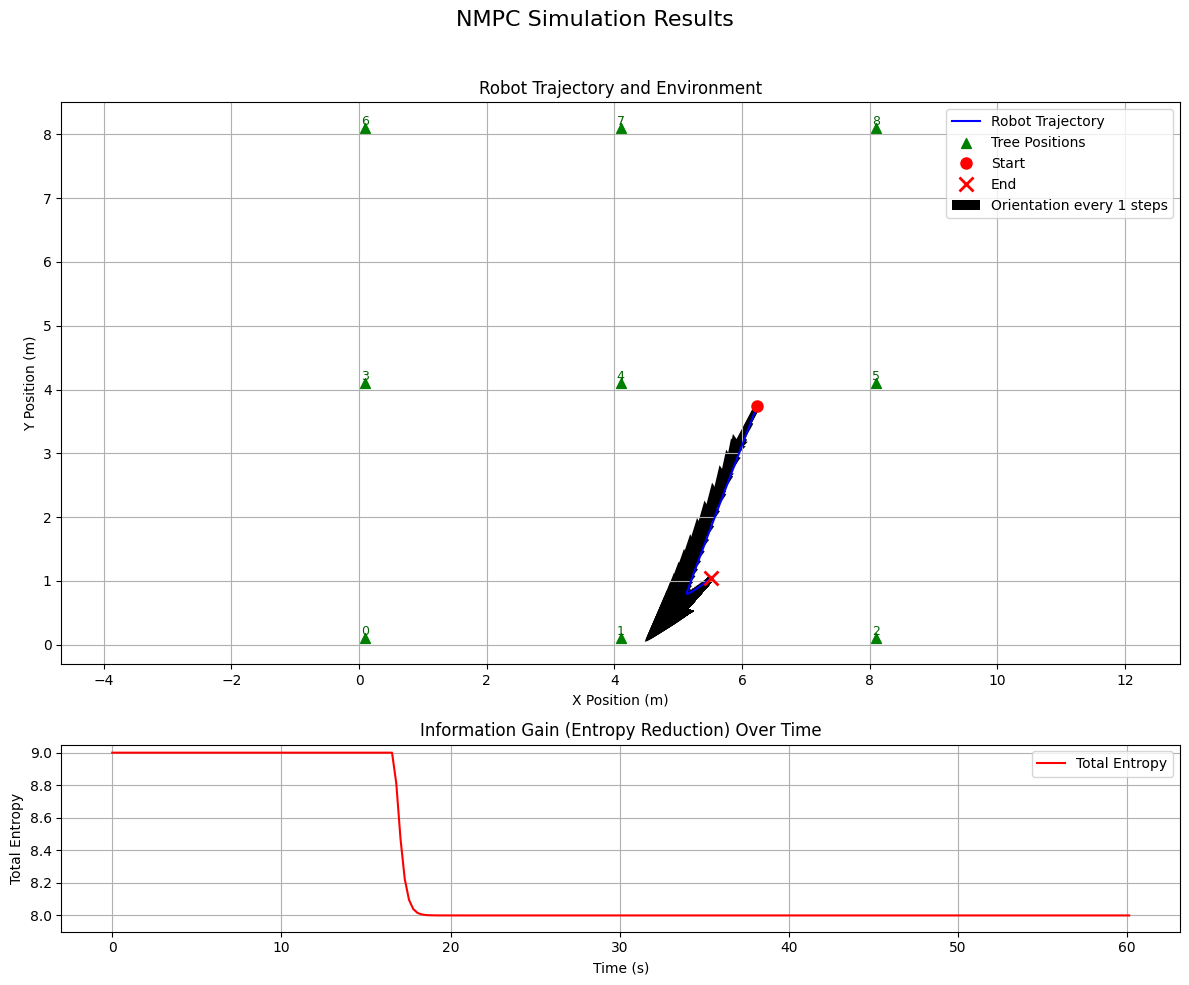

(180, 18)


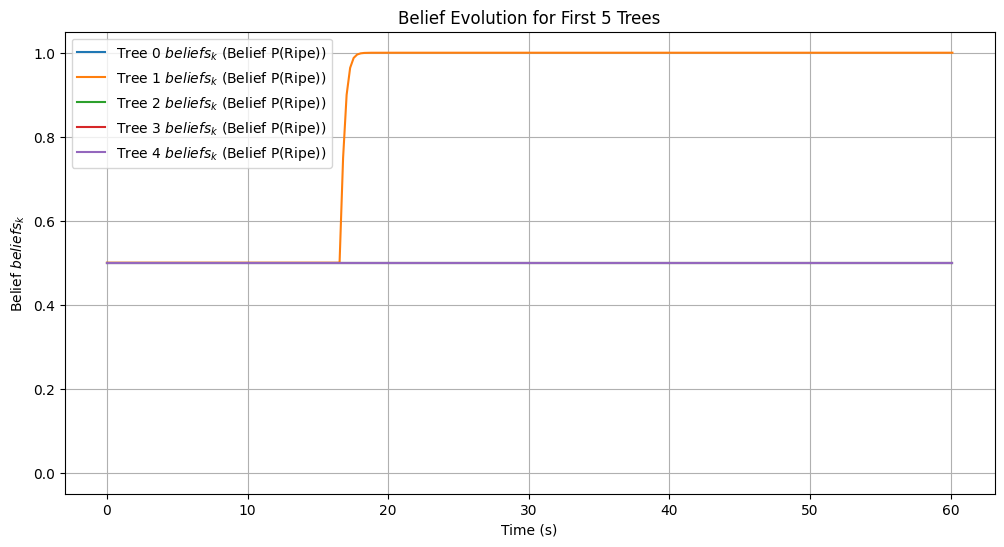

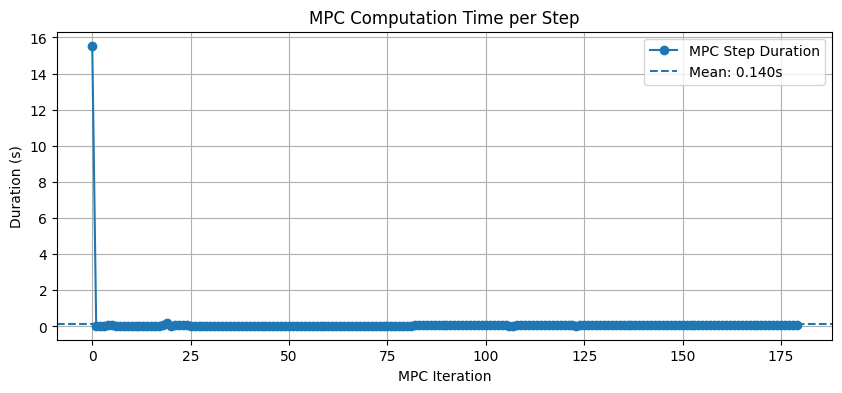

Cell 5: Plotting with Orientation - Complete (if data exists)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Cell 5: Plotting Results with Orientation every 20 steps
if not sim_time_points:
    print("No simulation data to plot.")
else:
    # Extract trajectory data
    poses_array = np.array(sim_actual_pose_history)  # shape (T, 3): [x, y, theta]
    robot_x_coords = poses_array[:, 0]
    robot_y_coords = poses_array[:, 1]
    robot_theta    = poses_array[:, 2]

    fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle('NMPC Simulation Results', fontsize=16)

    # Subplot 1: Robot Trajectory, Orientation, and Tree Positions
    axs[0].plot(robot_x_coords, robot_y_coords, '-b', label="Robot Trajectory")
    axs[0].scatter(sim_tree_positions[:, 0], sim_tree_positions[:, 1], 
                   c='g', marker='^', label="Tree Positions", s=50)
    for i, (tx, ty) in enumerate(sim_tree_positions):
        axs[0].text(tx, ty, str(i), fontsize=9, ha='center', va='bottom', color='darkgreen')

    # Mark start and end points
    axs[0].plot(robot_x_coords[0], robot_y_coords[0], 'ro', markersize=8, label="Start")
    axs[0].plot(robot_x_coords[-1], robot_y_coords[-1], 'rx', markersize=10, mew=2, label="End")

    # Plot orientation arrows every 20 steps
    step = 1
    axs[0].quiver(
        robot_x_coords[::step], robot_y_coords[::step],
        np.cos(robot_theta[::step]), np.sin(robot_theta[::step]),
        angles='xy', scale_units='xy', scale=1, width=0.005,
        label=f"Orientation every {step} steps"
    )

    axs[0].set_xlabel("X Position (m)")
    axs[0].set_ylabel("Y Position (m)")
    axs[0].set_title("Robot Trajectory and Environment")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].axis('equal')  # Ensure aspect ratio is equal

    # Subplot 2: Total Entropy Over Time
    axs[1].plot(sim_time_points, sim_entropy_history_total, '-r', label="Total Entropy")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Total Entropy")
    axs[1].set_title("Information Gain (Entropy Reduction) Over Time")
    axs[1].legend()
    axs[1].grid(True)
    if sim_entropy_history_total:
        min_ent = min(sim_entropy_history_total)
        axs[1].set_ylim(bottom=max(0, min_ent - 0.1))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Optional: Plot individual lambda beliefs for a few trees
    if sim_lambda_history and len(sim_lambda_history[0]) > 0:
        num_trees_to_plot = min(5, mpc_instance.num_total_trees)
        lambda_array = np.array(sim_lambda_history)
        print(lambda_array.shape)
        plt.figure(figsize=(12, 6))
        for i in range(num_trees_to_plot):
            plt.plot(sim_time_points, lambda_array[:, i*2], label=f"Tree {i} $beliefs_k$ (Belief P(Ripe))")
        plt.xlabel("Time (s)")
        plt.ylabel("Belief $beliefs_k$")
        plt.title(f"Belief Evolution for First {num_trees_to_plot} Trees")
        plt.legend()
        plt.grid(True)
        plt.ylim([-0.05, 1.05])
        plt.show()

    # Optional: Plot MPC step durations
    if sim_mpc_durations:
        plt.figure(figsize=(10, 4))
        plt.plot(sim_mpc_durations, marker='o', linestyle='-', label="MPC Step Duration")
        plt.xlabel("MPC Iteration")
        plt.ylabel("Duration (s)")
        plt.title("MPC Computation Time per Step")
        if len(sim_mpc_durations) > 1:
            mean_dur = np.mean(sim_mpc_durations)
            plt.axhline(mean_dur, linestyle='--', label=f"Mean: {mean_dur:.3f}s")
        plt.legend()
        plt.grid(True)
        plt.show()

print("Cell 5: Plotting with Orientation - Complete (if data exists)")
